<a href="https://colab.research.google.com/github/ElofssonLab/kb8029-book/blob/main/notebooks/day02-tensors-and-a-first-class.ipynb" style="display:inline-block;padding:10px 18px;background-color:#F9AB00;color:#000000;font-weight:bold;text-decoration:none;border-radius:6px;font-family:sans-serif;font-size:14px;">&#9654;&nbsp; Open in Google Colab</a>

# Day 2 — Programming in code: tensors, autograd, and a first class {.unnumbered}

The tensor/autograd sections below are reused directly from this course's own `notebooks/pytorch_bio_intro.ipynb` (only lightly trimmed) — no need to write this from scratch when it already existed and already uses a nice DNA-themed example. The exercises at the end are new, closing the loop with Day 1 and previewing Day 3.

# Day 2 — Programming Toolkit: NumPy/pandas/Matplotlib, Notebooks, Biopython, SciPy, scikit-learn, PyTorch

This notebook follows the book page in order: a quick NumPy/pandas/Matplotlib
recap, a real demonstration of why cell execution order matters, real
Biopython usage (a `Seq` object, `Bio.SeqIO`, and a live `Bio.Entrez`
fetch), a SciPy statistical test and a scikit-learn linear regression,
PyTorch tensors and autograd (reused from this course's own existing
material), opening a `.zip` archive, and finally the from-database-to-plot
worked example, plotted three times over.

In [1]:
# Section 1: Setup and installation checks
import torch, numpy as np, random, pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

PyTorch version: 2.5.1
CUDA available: True
Using device: cuda


## 1. NumPy, pandas, and Matplotlib: a quick recap

In [2]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(seed=0)
n_genes = 50
lengths = rng.integers(100, 1000, size=n_genes)
gc_content = np.clip(0.3 + 0.0003 * lengths + rng.normal(0, 0.03, size=n_genes), 0, 1)

genes = pd.DataFrame({
    "name": [f"gene_{i}" for i in range(n_genes)],
    "length": lengths,
    "gc_content": gc_content,
})
print(genes.head())
print()
print(genes.describe())

     name  length  gc_content
0  gene_0     865    0.562320
1  gene_1     673    0.479595
2  gene_2     560    0.440348
3  gene_3     342    0.388868
4  gene_4     377    0.419706

           length  gc_content
count   50.000000   50.000000
mean   512.520000    0.460031
std    273.843635    0.089423
min    102.000000    0.265995
25%    257.250000    0.385970
50%    566.500000    0.462944
75%    703.000000    0.532858
max    973.000000    0.636703


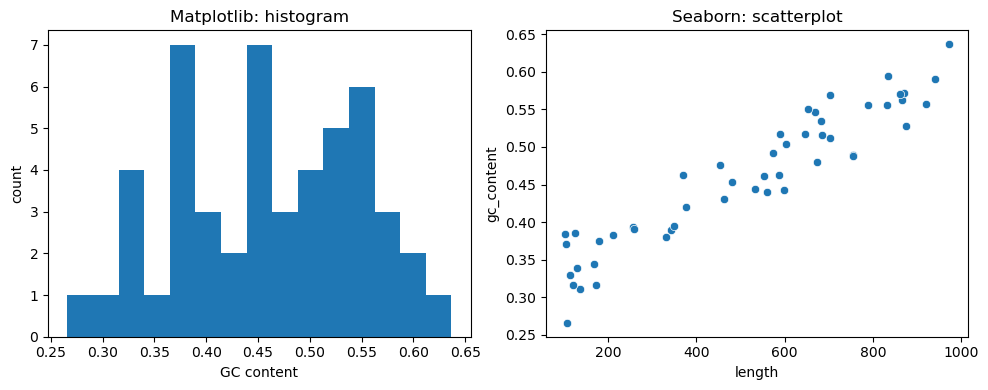

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(genes["gc_content"], bins=15)
axes[0].set_xlabel("GC content"); axes[0].set_ylabel("count")
axes[0].set_title("Matplotlib: histogram")
sns.scatterplot(data=genes, x="length", y="gc_content", ax=axes[1])
axes[1].set_title("Seaborn: scatterplot")
fig.tight_layout()
plt.show()

## 2. What notebooks are for: a real cell-order demonstration

Run the cell below, then run it again (and again) without re-running the
cell above it that sets `counter = 0`. The printed value keeps climbing —
`counter` is *not* reset by re-running "the same" cell, because the
variable lives in the notebook's memory, not on the page. This is the
exact mechanism behind the "stale value" gotcha described on the book
page: whatever a cell prints reflects the *last time it (and everything
it depends on) was actually run*, not its position on the page.

In [4]:
counter = 0
print(counter)

0


In [5]:
counter += 1
print("counter is now:", counter)
# Re-run THIS cell a few times (Shift+Enter repeatedly) without re-running
# the cell above -- the number keeps climbing. Then use "Restart and run
# all" and watch it reset to 1: that's the only way to be sure a notebook's
# state matches what's written on the page.

counter is now: 1


## 3. Biopython: sequences and databases

A real 30-nucleotide fragment of human beta-globin (*HBB*), fetched live
from NCBI (accession `NM_000518.5`) while writing this notebook.

In [6]:
from Bio.Seq import Seq
from Bio.SeqUtils import gc_fraction

# The first 10 codons of HBB's real coding sequence (NM_000518.5),
# fetched live via Bio.Entrez while writing this notebook.
bio_seq = Seq("ATGGTGCATCTGACTCCTGAGGAGAAGTCT")

print("sequence:           ", bio_seq)
print("length:              ", len(bio_seq))
print("GC fraction:         ", gc_fraction(bio_seq))
print("reverse complement:  ", bio_seq.reverse_complement())
print("translated (codons):", bio_seq.translate())

sequence:            ATGGTGCATCTGACTCCTGAGGAGAAGTCT
length:               30
GC fraction:          0.5
reverse complement:   AGACTTCTCCTCAGGAGTCAGATGCACCAT
translated (codons): MVHLTPEEKS


### `Bio.SeqIO`: parsing a FASTA file, not just one sequence

A single `Seq` object is the building block; real work means parsing a
*file* of them. `Bio.SeqIO` does that regardless of format (FASTA here,
but the same call works for GenBank, and more) — this is the
mechanism Day 3's database work builds on, just applied there to files
fetched live from NCBI/UniProt instead of a small local example.

In [7]:
from io import StringIO
from Bio import SeqIO

# A tiny two-record FASTA file, in memory (Bio.SeqIO works identically
# on a real file opened from disk -- StringIO just avoids writing one
# to disk for this small example).
fasta_text = """>HBB_fragment human beta-globin, first 10 codons (NM_000518.5)
ATGGTGCATCTGACTCCTGAGGAGAAGTCT
>toy_second_record a second, unrelated toy sequence
TTTTAAATTTAAATTT
"""

records = list(SeqIO.parse(StringIO(fasta_text), "fasta"))
print(f"parsed {len(records)} records:")
for rec in records:
    print(f"  {rec.id}: length {len(rec.seq)}, GC fraction {gc_fraction(rec.seq):.2f}")

parsed 2 records:
  HBB_fragment: length 30, GC fraction 0.50
  toy_second_record: length 16, GC fraction 0.00


### `Bio.Entrez`: actually reaching NCBI

The examples above used a sequence already typed in. `Bio.Entrez` is how
you get it live, over the network, straight from NCBI — this is the real
mechanism Day 3's database work uses at full scale.

In [8]:
from Bio import Entrez, SeqIO

Entrez.email = "arne@bioinfo.se"  # NCBI asks for a real contact email on every request

handle = Entrez.efetch(db="nuccore", id="NM_000518.5", rettype="gb", retmode="text")
hbb_record = SeqIO.read(handle, "genbank")
handle.close()

print("id:         ", hbb_record.id)
print("description:", hbb_record.description)
print("length:     ", len(hbb_record.seq))

id:          NM_000518.5
description: Homo sapiens hemoglobin subunit beta (HBB), mRNA
length:      628


## 4. SciPy: for statistics

Three examples, each tied to something this course does elsewhere.

### `scipy.stats.pearsonr`

In [9]:
from scipy import stats

r, p_value = stats.pearsonr(genes["length"], genes["gc_content"])
print(f"Pearson r = {r:.3f}, p = {p_value:.2e}")

Pearson r = 0.944, p = 9.78e-25


### `scipy.stats.ttest_ind` -- reproducing Day 1's t-test

Day 1 used Welch's t-test on these data ($t \approx -11.9$,
$p \approx 0.0001$). `equal_var=False` selects Welch's test; SciPy's
default is Student's test, which assumes equal variances.

In [10]:
control = [5.1, 4.9, 5.3, 5.0]
treatment = [7.2, 6.8, 7.5, 7.0]

t_stat, p_value = stats.ttest_ind(control, treatment, equal_var=False)   # Welch's t-test
print(f"t = {t_stat:.2f}, p = {p_value:.5f}")
assert abs(t_stat - (-11.9)) < 0.5, "should match Day 1's result"


t = -11.92, p = 0.00010


### `scipy.cluster.hierarchy` -- the algorithm behind Day 4's guide tree

Repeatedly merge the closest pair of clusters -- the algorithm
Day 4's guide-tree worked example does by hand on five toy sequences.
Here it runs on the 50 toy genes' length/GC-content features instead of
a real sequence-distance matrix, just to show the real function call.

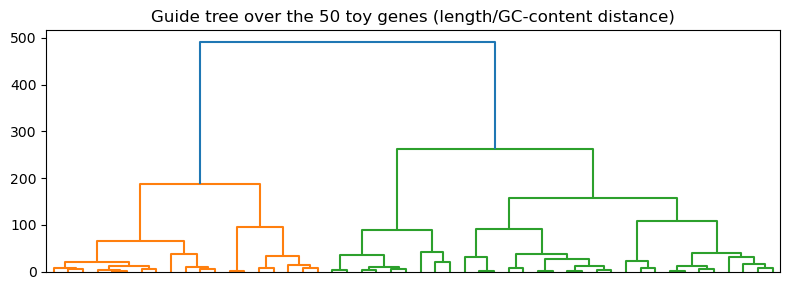

In [11]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt

distances = pdist(genes[["length", "gc_content"]])
merge_order = linkage(distances, method="average")

fig, ax = plt.subplots(figsize=(8, 3))
dendrogram(merge_order, no_labels=True, ax=ax)
ax.set_title("Guide tree over the 50 toy genes (length/GC-content distance)")
plt.tight_layout()
plt.show()


## 5. scikit-learn

Day 6 builds a linear model "by hand" with raw tensors and gradient
descent, precisely to see the mechanics. In practice, for a plain
linear regression like this one, you would normally just call
scikit-learn's implementation directly:

In [12]:
from sklearn.linear_model import LinearRegression

X = genes[["length"]]  # scikit-learn expects a 2D array of features
y = genes["gc_content"]

model = LinearRegression()
model.fit(X, y)

print("slope (per base):", model.coef_[0])
print("intercept:        ", model.intercept_)
print("R^2 on training data:", model.score(X, y))
print("(ground truth used to generate the data: slope=0.0003, intercept=0.3)")

slope (per base): 0.0003082228065033034
intercept:         0.3020608547966878
R^2 on training data: 0.8909068712829619
(ground truth used to generate the data: slope=0.0003, intercept=0.3)


**What else scikit-learn provides, for later** -- no code here, just
knowing these exist:

- `LogisticRegression` -- a classifier, not a regressor (linear score
  through a sigmoid, exactly Day 6's perceptron). The library version
  of what Days 6 and 8 build from scratch.
- `sklearn.model_selection.train_test_split` / `KFold` -- the library
  versions of the train/validation/test split and cross-validation
  Day 8 builds and explains by hand.
- `sklearn.neural_network.MLPClassifier` -- a real multilayer
  perceptron trained with backpropagation, all inside scikit-learn.
  Day 9 builds one from scratch specifically so the mechanics are
  visible; this is the library version.
- **XGBoost** (`xgboost.XGBClassifier`/`XGBRegressor`, a separate
  library, not scikit-learn itself, but deliberately `.fit()`/
  `.predict()`-compatible with it) -- gradient-boosted decision trees,
  a genuinely different and often very strong approach this course
  doesn't cover hands-on.

## 6. PyTorch: tensors, creation, shapes, and dtypes

In [13]:
# Small DNA example: 4 samples, 8 bases each encoded as ints 0-3
bases = np.array([
    [0,1,2,3,0,1,2,3],
    [3,3,2,2,1,1,0,0],
    [1,0,1,0,2,2,3,3],
    [2,2,1,1,0,0,3,3],
], dtype=np.int64)

tensor_from_np = torch.tensor(bases)                 # infers dtype/int64
float_tensor = torch.tensor(bases, dtype=torch.float32)
zeros = torch.zeros((2,3), dtype=torch.float32)
ones  = torch.ones((2,3), dtype=torch.float32)
rand  = torch.rand((2,3), dtype=torch.float32)

print("tensor_from_np:", tensor_from_np.shape, tensor_from_np.dtype)
print("float_tensor :", float_tensor.shape, float_tensor.dtype)
print("zeros shape   :", zeros.shape, "ones shape:", ones.shape, "rand shape:", rand.shape)

tensor_from_np: torch.Size([4, 8]) torch.int64
float_tensor : torch.Size([4, 8]) torch.float32
zeros shape   : torch.Size([2, 3]) ones shape: torch.Size([2, 3]) rand shape: torch.Size([2, 3])


### Basic tensor operations (indexing, slicing, reshaping)

In [14]:
data = float_tensor  # from earlier cell

first_two_samples = data[:2, :]          # slicing
first_four_features = data[:, :4]
reshaped = data.view(2, 2, 8)             # reshape into (batch, chunk, features)
concat = torch.cat([data, data], dim=0)   # stack samples

print("First two samples:\n", first_two_samples)
print("First four features of all samples:\n", first_four_features)
print("Reshaped (2,2,8):", reshaped.shape)
print("Concatenated shape:", concat.shape)

# Elementwise operations
mean_per_feature = data.mean(dim=0)
std_per_feature  = data.std(dim=0)
print("Feature means:", mean_per_feature)
print("Feature stds :", std_per_feature)

First two samples:
 tensor([[0., 1., 2., 3., 0., 1., 2., 3.],
        [3., 3., 2., 2., 1., 1., 0., 0.]])
First four features of all samples:
 tensor([[0., 1., 2., 3.],
        [3., 3., 2., 2.],
        [1., 0., 1., 0.],
        [2., 2., 1., 1.]])
Reshaped (2,2,8): torch.Size([2, 2, 8])
Concatenated shape: torch.Size([8, 8])
Feature means: tensor([1.5000, 1.5000, 1.5000, 1.5000, 0.7500, 1.0000, 2.0000, 2.2500])
Feature stds : tensor([1.2910, 1.2910, 0.5774, 1.2910, 0.9574, 0.8165, 1.4142, 1.5000])


### Autograd: gradients on simple functions

In [15]:
x = torch.linspace(-2, 2, steps=5, requires_grad=True)
y = (x**2).mean()  # simple function
print("y:", y.item())

y.backward()       # compute dy/dx
print("dy/dx:", x.grad)

y: 2.0
dy/dx: tensor([-0.8000, -0.4000,  0.0000,  0.4000,  0.8000])


## 6. Closing the loop with Day 1

Day 1's practice problems were done entirely by hand. Here they are again, this time in code — confirm you get the same answers.

In [16]:
import torch

# Day 1, practice problem 1: (2, -1, 3) . (1, 4, 0)
a = torch.tensor([2., -1., 3.])
b = torch.tensor([1., 4., 0.])
print("dot product:", torch.dot(a, b).item(), " (Day 1 answer: -2)")

# Day 1, practice problem 2: gradient of f(x0, x1) = 3*x0**2 + 2*x0*x1 at (1, 2)
x0 = torch.tensor(1., requires_grad=True)
x1 = torch.tensor(2., requires_grad=True)
f = 3*x0**2 + 2*x0*x1
f.backward()
print("gradient:", (x0.grad.item(), x1.grad.item()), " (Day 1 answer: (10, 2))")

dot product: -2.0  (Day 1 answer: -2)
gradient: (10.0, 2.0)  (Day 1 answer: (10, 2))


## 7. Opening compressed and archive files

Downloaded datasets -- including this course's own capstone project data
-- routinely arrive compressed. `.zip` archives (below) are one common
case; `.gz` files (also below) are the one you'll see constantly in
bioinformatics specifically, since real sequence data is almost always
distributed as `.fasta.gz`/`.fastq.gz`. Both examples build a small file
first (so they're self-contained), then do what you'd do with a
real downloaded one.

In [17]:
import zipfile
from pathlib import Path

# Build a small zip archive to demonstrate on (a real downloaded dataset
# already has one -- this just avoids depending on a network download
# for this example).
demo_dir = Path("zip_demo")
demo_dir.mkdir(exist_ok=True)
zip_path = demo_dir / "example_dataset.zip"

with zipfile.ZipFile(zip_path, "w") as zf:
    zf.writestr("dataset/seq1.fasta", ">seq1\nATGGTGCATCTGACTCCTGAG\n")
    zf.writestr("dataset/seq2.fasta", ">seq2\nTTTTAAATTTAAATTT\n")
    zf.writestr("dataset/readme.txt", "Two toy FASTA files.\n")

# --- This is the part that matters: opening someone else's zip file ---
with zipfile.ZipFile(zip_path) as zf:
    print("Contents of the archive:")
    for name in zf.namelist():
        print(" ", name)

    extract_dir = demo_dir / "extracted"
    zf.extractall(extract_dir)
    print()
    print(f"Extracted to {extract_dir}/:")
    for p in sorted(extract_dir.rglob("*")):
        if p.is_file():
            print(" ", p.relative_to(extract_dir))

# Clean up so re-running this cell (or the whole notebook) stays tidy.
import shutil
shutil.rmtree(demo_dir)

Contents of the archive:
  dataset/seq1.fasta
  dataset/seq2.fasta
  dataset/readme.txt

Extracted to zip_demo/extracted/:
  dataset/readme.txt
  dataset/seq1.fasta
  dataset/seq2.fasta


### `.gz` files: no separate extraction step

Unlike a `.zip` archive, a `.gz` file isn't a container of multiple
files -- it's a single compressed stream. `gzip.open(path, "rt")` gives
you a regular readable text file handle directly, with no extraction
step at all. `Bio.SeqIO.parse` (from the Biopython section above)
doesn't care whether the handle it's given is compressed -- hand it a
`gzip.open(...)` handle directly and it parses records straight out of
the compressed file.

In [18]:
import gzip
from pathlib import Path
from Bio import SeqIO

# Build a small gzipped FASTA file to demonstrate on (a real downloaded
# FASTQ/FASTA file already comes this way -- this just avoids depending
# on a network download for this example).
demo_dir = Path("gzip_demo")
demo_dir.mkdir(exist_ok=True)
gz_path = demo_dir / "example_sequences.fasta.gz"

fasta_text = ">seq1\nATGGTGCATCTGACTCCTGAG\n>seq2\nTTTTAAATTTAAATTT\n"
with gzip.open(gz_path, "wt") as f:
    f.write(fasta_text)

# --- This is the part that matters: reading someone else's .gz file ---
# 1) As plain text, no separate extraction step:
with gzip.open(gz_path, "rt") as f:
    text = f.read()
print("Read directly from the compressed file:")
print(text)

# 2) Bio.SeqIO parses records straight out of the compressed handle:
with gzip.open(gz_path, "rt") as f:
    records = list(SeqIO.parse(f, "fasta"))
print(f"Bio.SeqIO parsed {len(records)} records directly from the .gz file:")
for r in records:
    print(" ", r.id, "-", r.seq)

# Clean up so re-running this cell (or the whole notebook) stays tidy.
import shutil
shutil.rmtree(demo_dir)


Read directly from the compressed file:
>seq1
ATGGTGCATCTGACTCCTGAG
>seq2
TTTTAAATTTAAATTT

Bio.SeqIO parsed 2 records directly from the .gz file:
  seq1 - ATGGTGCATCTGACTCCTGAG
  seq2 - TTTTAAATTTAAATTT


## 8. Putting it together: from database to plot

**Step 1 — Biopython, for real data**: five real human globin genes,
fetched live from NCBI.

In [19]:
from Bio import Entrez, SeqIO

Entrez.email = "arne@bioinfo.se"

gene_accessions = {
    "HBB": "NM_000518.5",
    "HBA1": "NM_000558.5",
    "HBA2": "NM_000517.6",
    "MB": "NM_001382809.1",
    "NGB": "NM_021257.4",
}

records = {}
for symbol, acc in gene_accessions.items():
    handle = Entrez.efetch(db="nuccore", id=acc, rettype="gb", retmode="text")
    records[symbol] = SeqIO.read(handle, "genbank")
    handle.close()
    print(f"{symbol:5s} {acc:18s} length={len(records[symbol].seq):5d}  {records[symbol].description}")

HBB   NM_000518.5        length=  628  Homo sapiens hemoglobin subunit beta (HBB), mRNA


HBA1  NM_000558.5        length=  577  Homo sapiens hemoglobin subunit alpha 1 (HBA1), mRNA


HBA2  NM_000517.6        length=  576  Homo sapiens hemoglobin subunit alpha 2 (HBA2), mRNA


MB    NM_001382809.1     length= 1286  Homo sapiens myoglobin (MB), transcript variant 5, mRNA


NGB   NM_021257.4        length= 1778  Homo sapiens neuroglobin (NGB), mRNA


**Step 2 — pandas, SciPy, and Matplotlib, on a real published dataset.**
Real mouse liver RNA-seq differential expression (Becares et al. 2019,
*Cell Reports*), already processed with DESeq2, shared as example data
by VolcaNoseR (Goedhart & Luijsterburg, 2020). Loaded directly from its
public source -- no simulation needed this time.

In [20]:
import pandas as pd
import numpy as np
from scipy import stats

volcano_url = (
    "https://raw.githubusercontent.com/JoachimGoedhart/VolcaNoseR/"
    "master/Becares-diffgenes_HFHC.csv"
)
df = pd.read_csv(volcano_url)
print(f"Loaded {len(df)} real genes from Becares et al. (2019).")
print(df[["Gene", "log2_FoldChange", "pvalue", "minus_log10_pvalue"]].head())

# Sanity check: does the dataset's own precomputed -log10(p) column
# actually match -log10 of its own p-value column? (A real verification
# of data we didn't generate ourselves, not a formality.)
recomputed = -np.log10(df["pvalue"])
r, _ = stats.pearsonr(recomputed, df["minus_log10_pvalue"])
print(f"\nPearson r between recomputed and provided -log10(p): {r:.6f}")
assert r > 0.999, "the dataset's own significance columns should agree almost exactly"

# The single most significant gene, and the single largest fold change --
# worth checking whether they're the same gene.
top_significant = df.loc[df["minus_log10_pvalue"].idxmax()]
top_foldchange = df.loc[df["log2_FoldChange"].abs().idxmax()]
print(f"\nMost significant gene:    {top_significant['Gene']} "
      f"(log2FC={top_significant['log2_FoldChange']:.2f}, "
      f"-log10(p)={top_significant['minus_log10_pvalue']:.2f})")
print(f"Largest fold-change gene: {top_foldchange['Gene']} "
      f"(log2FC={top_foldchange['log2_FoldChange']:.2f}, "
      f"-log10(p)={top_foldchange['minus_log10_pvalue']:.2f})")

Loaded 3001 real genes from Becares et al. (2019).
    Gene  log2_FoldChange    pvalue  minus_log10_pvalue
0   A1bg         1.251613  0.000028            4.555955
1   A1cf         0.744592  0.000102            3.989331
2  Aadac         0.687958  0.000011            4.954677
3  Aadat         0.603443  0.000878            3.056310
4  Aaed1         0.421805  0.028833            1.540107

Pearson r between recomputed and provided -log10(p): 1.000000

Most significant gene:    Osbpl3 (log2FC=-1.63, -log10(p)=21.20)
Largest fold-change gene: Cyp2c69 (log2FC=2.39, -log10(p)=17.12)


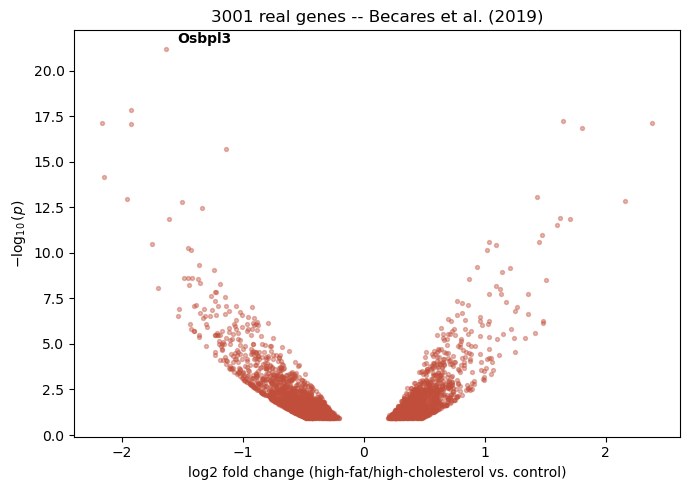

In [21]:
import matplotlib.pyplot as plt

log2fcs = df["log2_FoldChange"].to_numpy()
neglog10p = df["minus_log10_pvalue"].to_numpy()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(log2fcs, neglog10p, s=8, alpha=0.4, color="#c14e3a")
ax.annotate(
    top_significant["Gene"],
    (top_significant["log2_FoldChange"], top_significant["minus_log10_pvalue"]),
    textcoords="offset points", xytext=(8, 4), fontsize=10, fontweight="bold",
)
ax.set_xlabel("log2 fold change (high-fat/high-cholesterol vs. control)")
ax.set_ylabel(r"$-\log_{10}(p)$")
ax.set_title(f"{len(df)} real genes -- Becares et al. (2019)")
plt.tight_layout()
plt.savefig("../figs/day02-volcano-plot.png", dpi=150)
plt.show()

**Step 3 — the notebook payoff.** Re-run the same plot on the same real
data with a different color scheme:

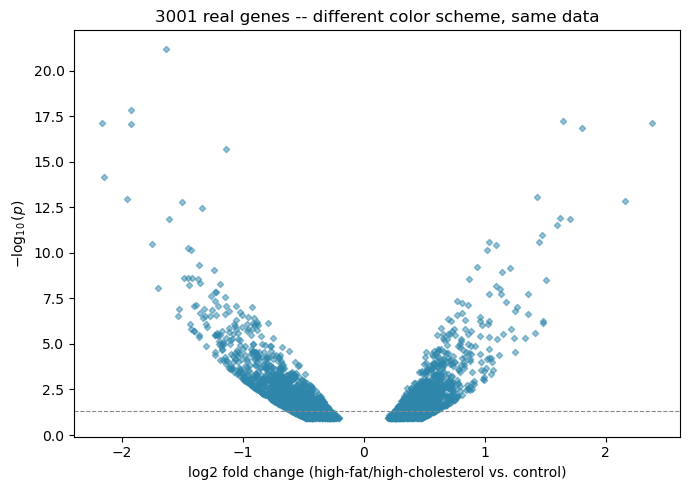

In [22]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(log2fcs, neglog10p, s=10, alpha=0.5, color="#2e86ab", marker="D")
ax.axhline(-np.log10(0.05), color="#888", linestyle="--", linewidth=0.8)
ax.set_xlabel("log2 fold change (high-fat/high-cholesterol vs. control)")
ax.set_ylabel(r"$-\log_{10}(p)$")
ax.set_title(f"{len(df)} real genes -- different color scheme, same data")
plt.tight_layout()
plt.show()

And highlighting the gene with the single **largest fold change**
instead -- notice it's not the same gene as the most significant one
above:

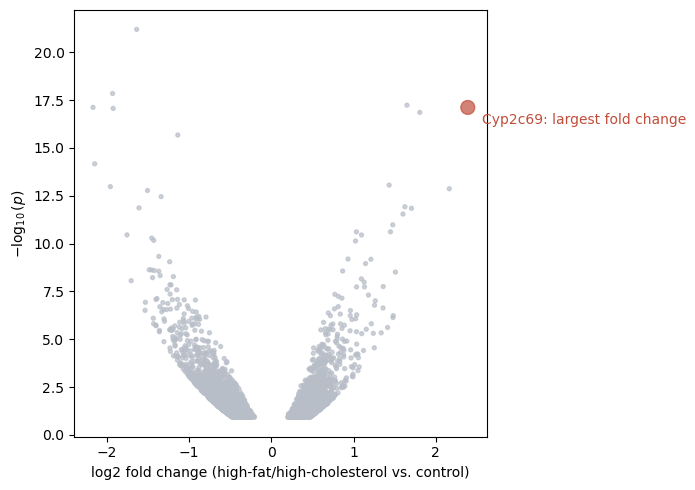

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))
is_top_fc = df["Gene"] == top_foldchange["Gene"]
colors = np.where(is_top_fc, "#c14e3a", "#b8bec8")
sizes = np.where(is_top_fc, 100, 8)
ax.scatter(log2fcs, neglog10p, s=sizes, color=colors, alpha=0.7)
ax.annotate(
    f"{top_foldchange['Gene']}: largest fold change",
    (top_foldchange["log2_FoldChange"], top_foldchange["minus_log10_pvalue"]),
    textcoords="offset points", xytext=(10, -12), fontsize=10, color="#c14e3a",
)
ax.set_xlabel("log2 fold change (high-fat/high-cholesterol vs. control)")
ax.set_ylabel(r"$-\log_{10}(p)$")
plt.tight_layout()
plt.show()

## Try it yourself

Pick a different real gene (any valid RefSeq accession), fetch it with
`Bio.Entrez` the same way, and add it to the volcano-plot example above.